In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
run_name = "run_baseline_1_vYuhan"

In [3]:
i = np.load("./complete_pipeline/out/"+run_name+"/original_i.npy")
i_clust = np.load("./complete_pipeline/out/"+run_name+"/cs_clusters.npy")
i.shape, i_clust.shape

((1931, 3), (1931,))

In [4]:
df = pd.DataFrame(np.column_stack((i,i_clust)),columns=["orientation","spatial_frequency","phase","CS_class"])
num_clusters = int(df.CS_class.max()+1)
df

,orientation,spatial_frequency,phase,CS_class
0,0.0,0.04,0.25,1.0
1,0.0,0.32,0.00,4.0
2,90.0,0.08,0.75,0.0
3,0.0,0.02,0.75,0.0
4,90.0,0.08,0.00,2.0
...,...,...,...,...
1926,0.0,0.16,0.75,3.0
1927,90.0,0.16,0.00,3.0
1928,90.0,0.08,0.75,0.0
1929,90.0,0.32,0.75,3.0


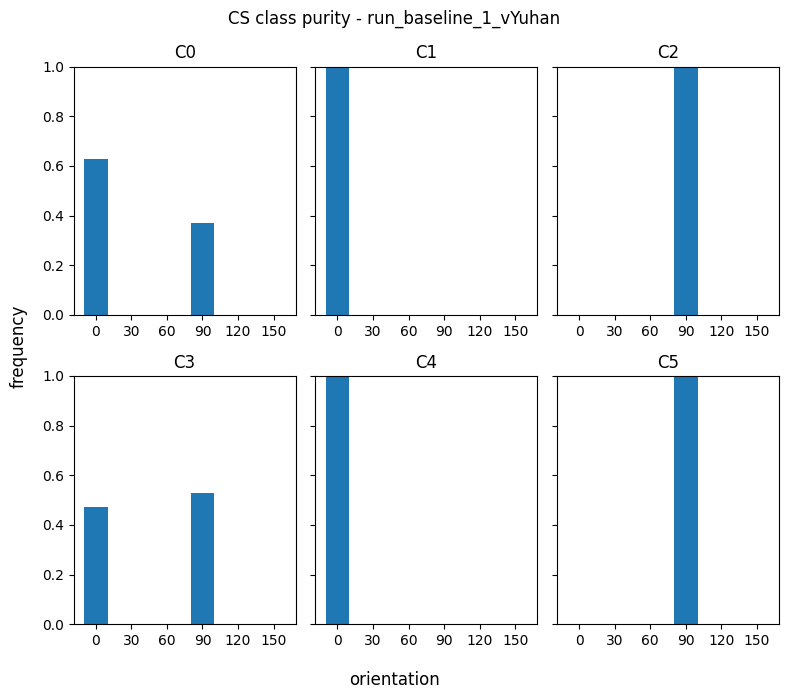

In [5]:
n_cols = 3
n_rows = num_clusters//n_cols + 1 if num_clusters%n_cols!=0 else num_clusters//n_cols
fig, ax = plt.subplots(nrows=n_rows,ncols=n_cols,sharey=True,figsize=(8,7))
for c in range(num_clusters):
    clust_data = df[df.CS_class==c]
    ax[c//n_cols,c%n_cols].hist(clust_data.orientation,weights=[1/clust_data.shape[0]]*clust_data.shape[0],bins=[-10,10,20,40,50,70,80,100,110,130,140,160])
    ax[c//n_cols,c%n_cols].set_title(f"C{c}")
    ax[c//n_cols,c%n_cols].set_xticks([0,30,60,90,120,150])
ax[0,0].set_ylim(0,1)
fig.suptitle(f"CS class purity - {run_name}")
fig.supxlabel("orientation")
fig.supylabel("frequency")
plt.tight_layout()
plt.show()